In [5]:
%pip install statsmodels matplotlib pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# 시각화 패키지
import seaborn as sns
# 데이터프레임 처리      
import pandas as pd
# 수치 계산        
import numpy as np    
# 그래프 그리기     
import matplotlib.pyplot as plt 
# 통계 분석 라이브러리 
import statsmodels.api as sm     

In [6]:
# https://www.statsmodels.org/stable/datasets/index.html#available-datasets

In [7]:
# 1949년 ~ 1960년까지 국제 항공 여객 수 Monthly 데이터
df = sm.datasets.get_rdataset("AirPassengers").data

In [8]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
# 데이터의 첫 5개 행 미리보기
df.head()  

,time,value
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132
3,1949.250000,129
4,1949.333333,121


In [ ]:
# 데이터의 마지막 5개 행 미리보기
df.tail()   

,value,rolling_mean,rolling_std,log_passengers,diff1,seasonal_diff
date,,,,,,
1960-08-01 19:30:00.000212872,606,463.333333,83.630500,6.406880,-0.026060,0.080731
1960-09-01 06:00:00.000102859,508,467.083333,84.617276,6.230481,-0.176399,0.092754
1960-10-01 16:30:00.000000000,461,471.583333,82.541954,6.133398,-0.097083,0.124585
1960-11-01 03:00:00.000212872,390,473.916667,79.502382,5.966147,-0.167251,0.074503
1960-12-01 13:30:00.000102859,432,476.166667,77.737125,6.068426,0.102279,0.064539


In [11]:
print(df.shape)

(144, 2)


In [ ]:
# 실제 날짜(datetime)로 변환하여 'date' 컬럼을 생성한다.
df['date'] = pd.to_datetime('1949-01-01') + pd.to_timedelta((df['time'] - 1949) * 365.25, unit='D')

# 생성한 'date' 컬럼을 시계열 인덱스로 설정한다.
df.set_index('date', inplace=True)

# 더 이상 필요 없는 'time' 컬럼을 삭제한다.
df.drop(columns='time', inplace=True)

In [ ]:
# 시계열 데이터 시각화
df.head()

,value
date,
1949-01-01 00:00:00.000000000,112
1949-01-31 10:29:59.999897149,118
1949-03-02 21:00:00.000102850,132
1949-04-02 07:30:00.000000000,129
1949-05-02 17:59:59.999897149,121


In [ ]:
# 시계열 데이터 요약 통계량 출력
df.describe()

,value
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [ ]:
# 데이터프레임의 전체 구조를 출력한다.
df.info() 

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 00:00:00 to 1960-12-01 13:30:00.000102859
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   value   144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [ ]:
# 각 컬럼별 결측치(null) 개수를 집계해서 보여준다.
df.isnull().sum() 

value    0
dtype: int64

In [ ]:
# 결측치가 포함된 행들을 모두 제거한다.
df.dropna(inplace=True) 

<Axes: xlabel='date'>

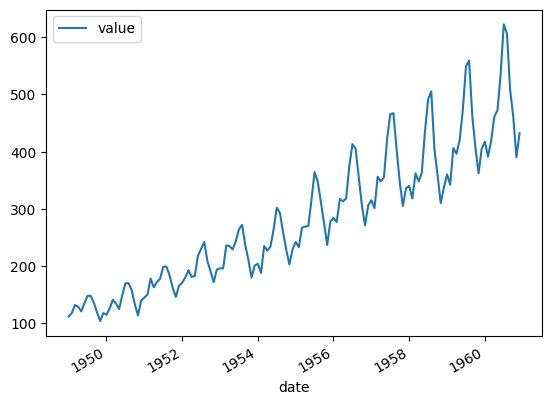

In [ ]:
# 시계열 인덱스라면 자동으로 날짜를 x축으로 사용하여 라인 플롯을 그린다.
df.plot() 

In [28]:
# AR(AutoRegressive): 과거의 실제 관측값들로 현재를 예측
# MA(Moving Average): 과거의 예측 오차들로 현재를 예측
# ARMA = AR + MA
# 통계적 모델은 '데이터의 계절성과 추세가 뚜렷하다'라는 전제하에 사용되는 경량 모델

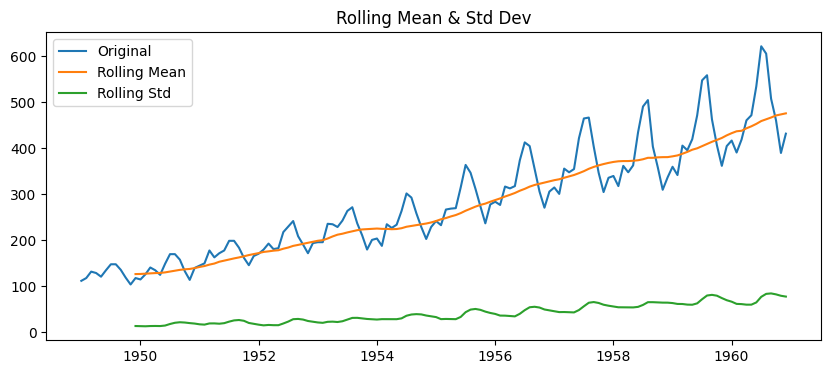

In [29]:
# 12개월(1년) 기준 이동 평균을 계산하여 'rolling_mean' 컬럼 생성
# → 추세(Trend) 식별, 노이즈 제거, 계절성 분석에 활용
df['rolling_mean'] = df['value'].rolling(window=12).mean()

# 12개월(1년) 기준 이동 표준편차를 계산하여 'rolling_std' 컬럼 생성
# → 시간 흐름에 따른 변동성 변화를 파악 (값이 커지면 데이터가 평균 주변에서 더 넓게 퍼져 있다는 의미)
df['rolling_std'] = df['value'].rolling(window=12).std()


# 그래프 크기 설정
plt.figure(figsize=(10, 4))

# 원본 시계열 데이터
plt.plot(df['value'], label='Original')

# 이동 평균 라인
plt.plot(df['rolling_mean'], label='Rolling Mean')

# 이동 표준편차 라인
plt.plot(df['rolling_std'], label='Rolling Std')

# 범례 및 제목 설정
plt.legend()
plt.title('Rolling Mean & Std Dev')

# 시각화 출력
plt.show()

In [ ]:
# 로그 변환을 통해 데이터의 분포를 안정화하고, 계절성 및 추세 분석에 도움을 준다.
df['log_passengers'] = np.log(df['value'])

In [31]:
# 1차 차분과 12개월(1년) 계절 차분을 계산하여 각각 'diff1'과 'seasonal_diff' 컬럼 생성
df['diff1'] = df['log_passengers'].diff().dropna()
df['seasonal_diff'] = df['log_passengers'].diff(12).dropna()

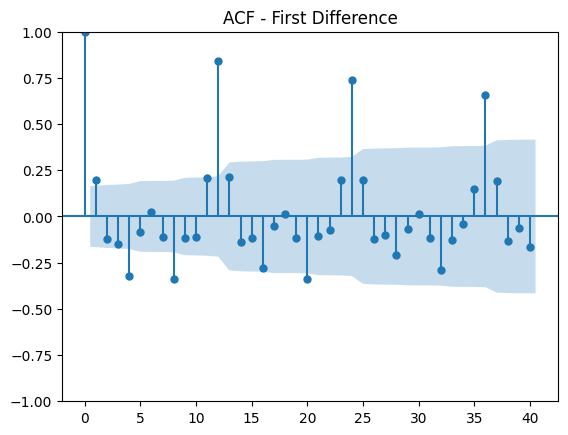

In [32]:
# ACF(Autocorrelation Function)와 PACF 시각화를 위한 패키지 불러오기
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF 플롯: 로그 변환 후 1차 차분한 시계열에 대해 자기상관을 확인
# → ACF는 시점 t와 시점 t-k 값이 얼마나 선형적으로 관계되는지를 나타낸다.
# → 특정 시점(k)에서 값이 급격히 감소하는 지점(컷오프)을 통해 MA(q) 차수를 추정할 수 있다.
plot_acf(df['log_passengers'].diff().dropna(), lags=40)  # 최대 40개 지연(lag)까지 확인

# 그래프 제목 설정
plt.title('ACF - First Difference')

# 그래프 출력
plt.show()

In [34]:
# ACF(Autocorrelation Function) 계산을 위한 함수 불러오기
from statsmodels.tsa.stattools import acf

# 로그 변환 후 1차 차분한 시계열에 대해 ACF 값을 계산한다.
# nlags=40 → 최대 40개의 지연(lag)에 대한 자기상관 계수를 반환
acf_values = acf(df['log_passengers'].diff().dropna(), nlags=40)

# ACF 값을 시각화/분석하기 쉽게 DataFrame 형태로 변환한다.
# lag: 시차(k), acf: 해당 시차에서의 자기상관 계수
acf_df = pd.DataFrame({
    'lag': range(len(acf_values)),
    'acf': acf_values
})

In [35]:
acf_df.head(30)

,lag,acf
0,0,1.000000
1,1,0.199751
2,2,-0.120104
3,3,-0.150772
4,4,-0.322074
5,5,-0.083975
6,6,0.025778
7,7,-0.110961
8,8,-0.336721
9,9,-0.115586


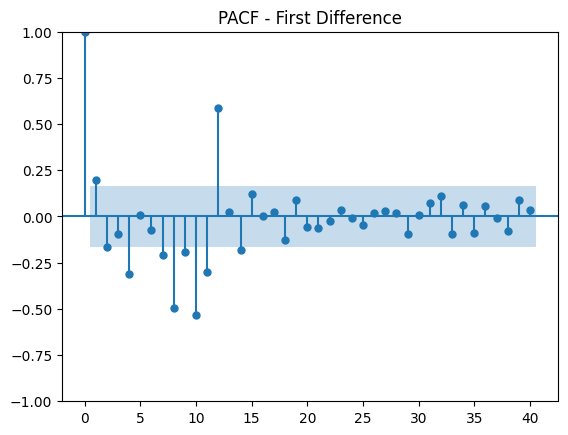

In [36]:
# PACF(Partial Autocorrelation Function) 플롯을 그린다.
# → PACF는 lag k에서의 '순수한 상관관계'를 보여주며,
#   중간 lag들(t-1, t-2, ..., t-k+1)의 영향을 제거한 후의 자기상관을 나타낸다.
# → PACF에서 급격히 감소(cut-off)하는 지점은 AR(p) 차수 선택에 활용된다.
plot_pacf(df['log_passengers'].diff().dropna(), lags=40)

# 그래프 제목 설정
plt.title('PACF - First Difference')

# 그래프 출력
plt.show()

In [43]:
# PACF(Partial Autocorrelation Function) 값을 계산하기 위한 함수 불러오기
# → PACF는 특정 lag(k)에서의 '순수한 자기상관'을 측정하며,
#   중간 지연값들의 영향을 제거한 뒤의 상관관계를 보여준다.
from statsmodels.tsa.stattools import pacf

# 로그 변환 후 1차 차분한 시계열에 대해 PACF 값을 계산한다.
# nlags=40 → 최대 40개의 지연(lag)에 대한 부분 자기상관 계수 반환
pacf_values = pacf(df['log_passengers'].diff().dropna(), nlags=40)

# PACF 값을 분석하기 쉽게 DataFrame 형태로 변환한다.
# lag: 시차(k), pacf: 해당 시차에서의 부분 자기상관 계수
pacf_df = pd.DataFrame({
    'lag': range(len(acf_values)),   # ⚠ acf_values 아닌 pacf_values 길이를 쓰는 것이 일반적
    'pacf': pacf_values
})


In [44]:
pacf_df.head(30)

,lag,pacf
0,0,1.000000
1,1,0.201158
2,2,-0.169116
3,3,-0.097992
4,4,-0.320381
5,5,0.007670
6,6,-0.078763
7,7,-0.222941
8,8,-0.533272
9,9,-0.236851


<Axes: xlabel='date'>

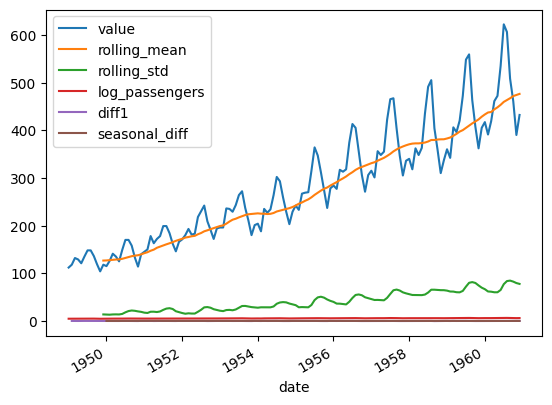

In [45]:
df.plot()

In [46]:
# ARIMA 모델을 사용하기 위한 클래스 불러오기
from statsmodels.tsa.arima.model import ARIMA

# ARIMA(2, 1, 2) 모델 생성
# p = 2 → AR(자기회귀) 차수
# d = 1 → 1차 차분(시계열을 정상성으로 만들기 위한 단계)
# q = 2 → MA(이동평균) 차수
# 'log_passengers' 시계열에 대해 ARIMA 모델을 학습할 준비를 한다.
model_arima = ARIMA(df['log_passengers'], order=(2, 1, 2))

# 모델 훈련(적합)
# → 최적의 AR, MA 계수 추정
# → 잔차(residual) 분석 및 예측을 수행할 수 있는 result 객체 반환
result_arima = model_arima.fit()

C:\Users\Shiverlog\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Shiverlog\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Shiverlog\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [47]:
# 예측할 기간(steps)을 설정한다.
# → 여기서는 향후 24개월(2년)을 예측하도록 지정.
n_periods = 24

# 학습된 ARIMA 모델(result_arima)을 이용하여 로그 변환된 값 기준으로 24개월 예측을 수행한다.
forecast_arima_log = result_arima.get_forecast(steps=n_periods)

# 예측 결과에 대응하는 미래 날짜 인덱스를 생성한다.
# → 기존 시계열의 마지막 날짜(df.index[-1]) 이후 1개월부터 시작
# → 월(Month Start, 'MS') 단위로 24개 생성
forecast_index = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=n_periods, freq='MS')

# ARIMA 예측값은 로그 스케일이므로,
# 원래 승객 수 스케일로 복원하기 위해 exp()를 적용한다.
forecast_arima = np.exp(forecast_arima_log.predicted_mean)

# 복원된 예측값에 우리가 생성한 미래 날짜 인덱스를 설정한다.
forecast_arima.index = forecast_index


C:\Users\Shiverlog\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Shiverlog\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


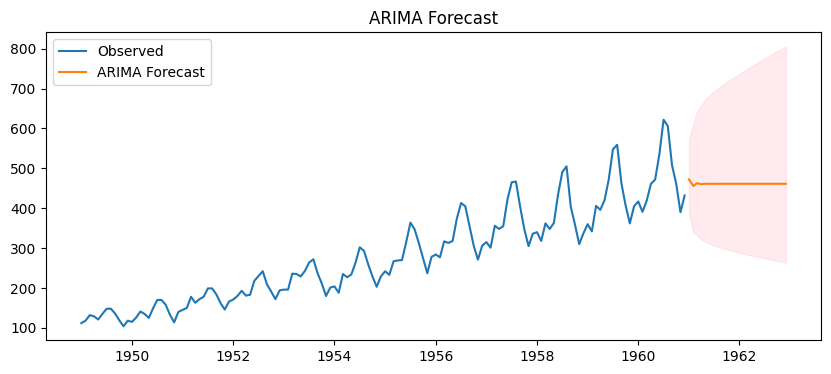

In [48]:
# 그래프 크기 설정
plt.figure(figsize=(10, 4))

# 실제 관측값 시계열을 플롯한다.
plt.plot(df['value'], label='Observed')

# ARIMA 모델이 예측한 미래값을 플롯한다.
plt.plot(forecast_arima, label='ARIMA Forecast')

# 예측 구간(Confidence Interval)을 시각화한다.
# → conf_int()는 로그 스케일에서의 신뢰구간이므로 exp()로 원래 스케일로 변환
# → 예측의 불확실성을 보여주는 영역(핑크색 반투명)
plt.fill_between(
    forecast_index,
    np.exp(forecast_arima_log.conf_int().iloc[:, 0]),  # CI 하한
    np.exp(forecast_arima_log.conf_int().iloc[:, 1]),  # CI 상한
    color='pink', alpha=0.3
)

# 범례 표시
plt.legend()

# 그래프 제목 설정
plt.title('ARIMA Forecast')

# 그래프 출력
plt.show()


In [ ]:
# SARIMAX(SARIMA) 모델 불러오기
# → SARIMA는 ARIMA에 '계절성(seasonality)' 요소를 추가한 시계열 모델이다.
# → 월별·분기별 패턴처럼 주기성이 뚜렷한 데이터(AirPassengers)에 매우 적합하다.
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA 모델 정의
# order = (1, 1, 1) → 비계절(non-seasonal) ARIMA 구성
#   p = 1 : AR(자기회귀) 차수
#   d = 1 : 1차 차분 (추세 제거)
#   q = 1 : MA(이동평균) 차수
#
# seasonal_order = (1, 1, 1, 12)
#   P = 1 : 계절 AR 차수
#   D = 1 : 계절 차분(12개월 주기)
#   Q = 1 : 계절 MA 차수
#   s = 12 : 계절 주기(월별 데이터 → 12개월)
model_sarima = SARIMAX(df['log_passengers'], 
                      order=(1, 1, 1), 
                      seasonal_order=(1, 1, 1, 12))

# SARIMA 모델 학습(적합)
# → 계절성 + 추세를 동시에 반영한 모델로 파라미터를 추정한다.
result_sarima = model_sarima.fit()

C:\Users\Shiverlog\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Shiverlog\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [50]:
# 학습된 SARIMA 모델을 이용해 향후 n_periods(예: 24개월)를 예측한다.
# 결과는 로그 스케일(log_passengers) 기준의 예측값으로 반환된다.
forecast_sarima_log = result_sarima.get_forecast(steps=n_periods)

# 로그 스케일에서 예측된 값을 원래 승객 수(value) 스케일로 변환하기 위해 exp()를 적용한다.
forecast_sarima = np.exp(forecast_sarima_log.predicted_mean)

# 예측값에 대응하는 미래 날짜 인덱스(월별)를 설정한다.
# → ARIMA 예측에서 사용한 것과 동일한 forecast_index를 SARIMA에도 재사용한다.
forecast_sarima.index = forecast_index

C:\Users\Shiverlog\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Shiverlog\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


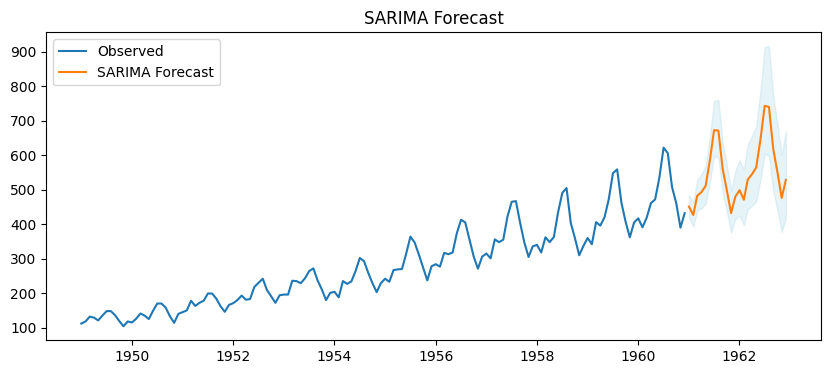

In [51]:
# 그래프 크기 설정
plt.figure(figsize=(10, 4))

# 실제 역사적 승객 수 시계열 데이터
plt.plot(df['value'], label='Observed')

# SARIMA 모델이 예측한 미래 승객 수
plt.plot(forecast_sarima, label='SARIMA Forecast')

# 예측 구간(Confidence Interval) 시각화
# conf_int() 반환값은 로그 스케일이므로, exp()를 통해 원래 스케일로 복원한다.
# 이 영역은 예측 불확실성을 나타내며, 라인 주변의 신뢰 범위를 보여준다.
plt.fill_between(
    forecast_index,
    np.exp(forecast_sarima_log.conf_int().iloc[:, 0]),  # CI 하한
    np.exp(forecast_sarima_log.conf_int().iloc[:, 1]),  # CI 상한
    color='lightblue', alpha=0.3
)

# 범례 추가
plt.legend()

# 그래프 제목
plt.title('SARIMA Forecast')

# 그래프 출력
plt.show()
